# RNN with Static Embeddings

## Imports

In [1]:
import pandas as pd
import numpy as np
import torch

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import matplotlib.pyplot as plt

from collections import Counter

## Load Data

In [2]:
df = pd.read_csv("output.csv")
df.head()

,movieId,title,genre,plot
0,1,Toy Story (1995),Adventure,"Led by Woody, Andy's toys live happily in his ..."
1,2,Jumanji (1995),Adventure,When siblings Judy and Peter discover an encha...
2,3,Grumpier Old Men (1995),Comedy,A family wedding reignites the ancient feud be...
3,4,Waiting to Exhale (1995),Comedy,"Cheated on, mistreated and stepped on, the wom..."
4,5,Father of the Bride Part II (1995),Comedy,Just when George Banks has recovered from his ...


In [3]:
df.columns

Index(['movieId', 'title', 'genre', 'plot'], dtype='object')

## Data Cleaning

In [4]:
# Check class distribution
label_counts = df["genre"].value_counts()
print(label_counts)

# Remove rare classes (less than 2 samples)
rare_labels = label_counts[label_counts < 2].index
df = df[~df["genre"].isin(rare_labels)].copy()

print("Removed classes:", list(rare_labels))
print("Remaining classes:", df["genre"].nunique())
print("\nUpdated class distribution:")
print(df["genre"].value_counts())

genre
Drama          1580
Comedy         1564
Action          745
Adventure       330
Horror          322
Crime           287
Documentary     158
Children        120
Animation        75
Thriller         69
Romance          41
Western          37
Mystery          33
Sci-Fi           33
Musical          21
Film-Noir        16
Fantasy          14
War              10
IMAX              1
Name: count, dtype: int64
Removed classes: ['IMAX']
Remaining classes: 18

Updated class distribution:
genre
Drama          1580
Comedy         1564
Action          745
Adventure       330
Horror          322
Crime           287
Documentary     158
Children        120
Animation        75
Thriller         69
Romance          41
Western          37
Mystery          33
Sci-Fi           33
Musical          21
Film-Noir        16
Fantasy          14
War              10
Name: count, dtype: int64


## Select Input and Labels

In [5]:
texts = df["plot"]
labels = df["genre"]

print(texts.head())
print(labels.head())

0    Led by Woody, Andy's toys live happily in his ...
1    When siblings Judy and Peter discover an encha...
2    A family wedding reignites the ancient feud be...
3    Cheated on, mistreated and stepped on, the wom...
4    Just when George Banks has recovered from his ...
Name: plot, dtype: object
0    Adventure
1    Adventure
2       Comedy
3       Comedy
4       Comedy
Name: genre, dtype: object


In [6]:
label_encoder = LabelEncoder()
labels_encoded = labels  # keep labels as strings for now

## Train / Validation / Test Split

In [7]:
# First split: train + temp
X_train, X_temp, y_train, y_temp = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

# Second split: validation + test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Train size: 4364
Validation size: 545
Test size: 546


In [8]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_val = label_encoder.transform(y_val)
y_test = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)

Classes: ['Action' 'Adventure' 'Animation' 'Children' 'Comedy' 'Crime'
 'Documentary' 'Drama' 'Fantasy' 'Film-Noir' 'Horror' 'Musical' 'Mystery'
 'Romance' 'Sci-Fi' 'Thriller' 'War' 'Western']


## Tokenization

In [9]:
def tokenize(text):
    return text.lower().split()

counter = Counter()

for text in X_train:
    tokens = tokenize(text)
    counter.update(tokens)

print("Total unique tokens:", len(counter))
print("Most common tokens:", counter.most_common(10))

Total unique tokens: 30883
Most common tokens: [('the', 10763), ('a', 9128), ('to', 6820), ('and', 6308), ('of', 5521), ('in', 3872), ('his', 3644), ('is', 2925), ('with', 2236), ('he', 1876)]


## Build Vocabulary

In [10]:
# Special tokens
vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

# Only keep reasonably frequent words
min_freq = 3

for word, freq in counter.items():
    if freq >= min_freq:
        vocab[word] = len(vocab)

print("Vocab size:", len(vocab))
print("Sample vocab:", list(vocab.items())[:10])
print("Min frequency threshold:", min_freq)

Vocab size: 8255
Sample vocab: [('<PAD>', 0), ('<UNK>', 1), ('feudal', 2), ('epic', 3), ('presents', 4), ('the', 5), ('tale', 6), ('of', 7), ('a', 8), ('petty', 9)]
Min frequency threshold: 3


## Convert Text to Sequences

In [11]:
MAX_LEN = 50  # fixed sequence length for RNN

def text_to_sequence(text):
    tokens = tokenize(text)
    seq = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
    
    # padding or truncation
    if len(seq) < MAX_LEN:
        seq += [vocab["<PAD>"]] * (MAX_LEN - len(seq))
    else:
        seq = seq[:MAX_LEN]
    
    return seq

In [12]:
sample_text = X_train.iloc[0]
print("Original text:\n", sample_text)

sample_seq = text_to_sequence(sample_text)
print("\nSequence:\n", sample_seq)
print("\nLength:", len(sample_seq))
print("Unique tokens in sequence:", len(set(sample_seq)))

Original text:
 Akira Kurosawa's lauded feudal epic presents the tale of a petty thief who is recruited to impersonate Shingen, an aging warlord, in order to avoid attacks by competing clans. When Shingen dies, his generals reluctantly agree to have the impostor take over as the powerful ruler. He soon begins to appreciate life as Shingen, but his commitment to the role is tested when he must lead his troops into battle against the forces of a rival warlord.

Sequence:
 [1, 1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 1, 16, 17, 1, 18, 19, 14, 20, 21, 22, 23, 1, 24, 1, 25, 26, 27, 28, 29, 14, 30, 5, 1, 31, 32, 33, 5, 34, 1, 35, 36, 37, 14]

Length: 50
Unique tokens in sequence: 37


## Dataset and DataLoader

In [13]:
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts.reset_index(drop=True)
        self.labels = np.array(labels)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts.iloc[idx]
        seq = text_to_sequence(text)
        label = int(self.labels[idx])

        return {
            "input_ids": torch.tensor(seq, dtype=torch.long),
            "label": torch.tensor(label, dtype=torch.long)
        }

In [14]:
train_dataset = TextDataset(X_train, y_train)
val_dataset = TextDataset(X_val, y_val)
test_dataset = TextDataset(X_test, y_test)

In [15]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [16]:
batch = next(iter(train_loader))

print("Input shape:", batch["input_ids"].shape)
print("Labels shape:", batch["label"].shape)

Input shape: torch.Size([32, 50])
Labels shape: torch.Size([32])


## Static Embeddings

In [17]:
EMBED_DIM = 100

print("Embedding dimension:", EMBED_DIM)
print("Embedding type: static (frozen during training)")

Embedding dimension: 100
Embedding type: static (frozen during training)


## RNN Model

In [18]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=0
        )
        self.embedding.weight.requires_grad = False

        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)

        output, hidden = self.rnn(embedded)

        last_hidden = hidden[-1]

        logits = self.fc(last_hidden)

        return logits

In [19]:
HIDDEN_DIM = 128
OUTPUT_DIM = len(label_encoder.classes_)

model = RNNClassifier(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM
)

print(model)

RNNClassifier(
  (embedding): Embedding(8255, 100, padding_idx=0)
  (rnn): RNN(100, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=18, bias=True)
)


In [20]:
batch = next(iter(train_loader))
output = model(batch["input_ids"])

print("Output shape:", output.shape)

Output shape: torch.Size([32, 18])


## Training Setup

In [21]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Setup complete")

Setup complete


## Training Loop

In [22]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    
    total_loss = 0
    
    for batch in loader:
        input_ids = batch["input_ids"]
        labels = batch["label"]
        
        optimizer.zero_grad()
        outputs = model(input_ids)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

## Evaluation

In [23]:
def evaluate(model, loader):
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"]
            labels = batch["label"]
            
            outputs = model(input_ids)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return all_labels, all_preds

## Train Model

In [24]:
EPOCHS = 5

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    
    y_true, y_pred = evaluate(model, val_loader)
    val_acc = accuracy_score(y_true, y_pred)
    val_f1 = f1_score(y_true, y_pred, average="weighted")

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")
    print(f"Val F1 (Weighted): {val_f1:.4f}")
    print("-" * 40)

Epoch 1/5
Train Loss: 2.0747
Val Accuracy: 0.2807
Val F1 (Weighted): 0.1605
----------------------------------------
Epoch 2/5
Train Loss: 1.9792
Val Accuracy: 0.2771
Val F1 (Weighted): 0.1752
----------------------------------------
Epoch 3/5
Train Loss: 1.9559
Val Accuracy: 0.2752
Val F1 (Weighted): 0.1744
----------------------------------------
Epoch 4/5
Train Loss: 1.9236
Val Accuracy: 0.3028
Val F1 (Weighted): 0.2014
----------------------------------------
Epoch 5/5
Train Loss: 1.8888
Val Accuracy: 0.2514
Val F1 (Weighted): 0.1784
----------------------------------------


## Evaluation Metrics

In [25]:
y_true, y_pred = evaluate(model, val_loader)

accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="weighted")

print("Validation Accuracy:", round(accuracy, 4))
print("Validation F1 (Weighted):", round(f1, 4))

Validation Accuracy: 0.2514
Validation F1 (Weighted): 0.1784


In [26]:
y_true_test, y_pred_test = evaluate(model, test_loader)

test_acc = accuracy_score(y_true_test, y_pred_test)
test_f1 = f1_score(y_true_test, y_pred_test, average="weighted")

print("Test Accuracy:", round(test_acc, 4))
print("Test F1 (Weighted):", round(test_f1, 4))

Test Accuracy: 0.3132
Test F1 (Weighted): 0.2451


## Test Set Evaluation

In [27]:
y_true_test, y_pred_test = evaluate(model, test_loader)

test_acc = accuracy_score(y_true_test, y_pred_test)
weighted_f1 = f1_score(y_true_test, y_pred_test, average="weighted")

print("Test Accuracy:", round(test_acc, 4))
print("Test F1 (Weighted):", round(weighted_f1, 4))

Test Accuracy: 0.3132
Test F1 (Weighted): 0.2451


## Confusion Matrix

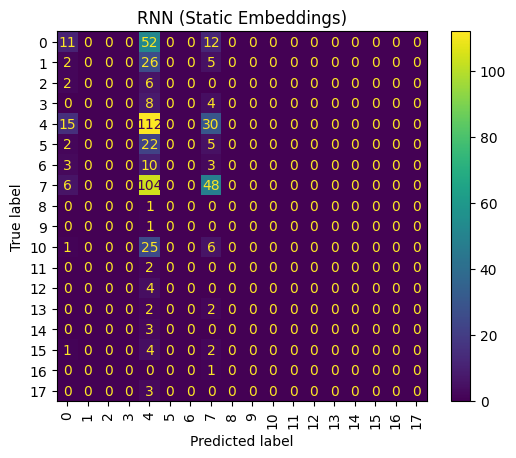

In [28]:
cm = confusion_matrix(y_true_test, y_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(xticks_rotation=90)
plt.title("RNN (Static Embeddings)")
plt.show()

In [29]:
for i, genre in enumerate(label_encoder.classes_):
    print(f"{i}: {genre}")

0: Action
1: Adventure
2: Animation
3: Children
4: Comedy
5: Crime
6: Documentary
7: Drama
8: Fantasy
9: Film-Noir
10: Horror
11: Musical
12: Mystery
13: Romance
14: Sci-Fi
15: Thriller
16: War
17: Western


## Model Results

In [30]:
results_df = pd.DataFrame({
    "Model": ["RNN (Static Embeddings)"],
    "F1 (Weighted)": [weighted_f1],
    "Accuracy": [test_acc],
    "Vocab Size": [len(vocab)],
    "Embedding Type": ["Static"],
    "Embedding Dim": [EMBED_DIM]
})

results_df

,Model,F1 (Weighted),Accuracy,Vocab Size,Embedding Type,Embedding Dim
0,RNN (Static Embeddings),0.245101,0.313187,8255,Static,100


In [31]:
most_common = Counter(y_train).most_common(1)[0][0]
y_pred_majority = [most_common] * len(y_test)

maj_accuracy = accuracy_score(y_test, y_pred_majority)
maj_f1 = f1_score(y_test, y_pred_majority, average="weighted")


# Random baseline
import numpy as np

num_classes = len(label_encoder.classes_)
y_pred_random = np.random.randint(0, num_classes, size=len(y_test))

rand_accuracy = accuracy_score(y_test, y_pred_random)
rand_f1 = f1_score(y_test, y_pred_random, average="weighted")

In [32]:
comparison_df = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Random Baseline",
        "RNN (Static Embeddings)"
    ],
    "F1 (Weighted)": [
        maj_f1,
        rand_f1,
        weighted_f1
    ],
    "Accuracy": [
        maj_accuracy,
        rand_accuracy,
        test_acc
    ]
})

comparison_df

,Model,F1 (Weighted),Accuracy
0,Majority Baseline,0.129891,0.289377
1,Random Baseline,0.084603,0.062271
2,RNN (Static Embeddings),0.245101,0.313187


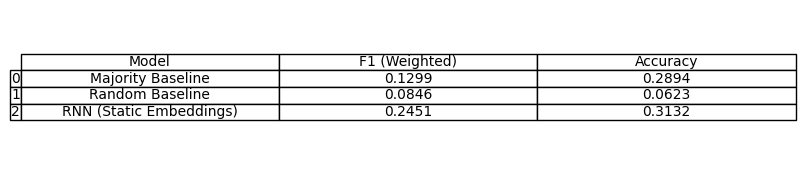

In [33]:
fig, ax = plt.subplots(figsize=(10, 2))

ax.axis('off')

table = pd.plotting.table(
    ax,
    comparison_df.round(4),
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)

plt.savefig('comparison-results.png', bbox_inches='tight', dpi=150)
plt.show()